# Chapter 7: Regularization, Ridge and Lasso
### MATH 4230 Capstone Project
**Dataset:** Student Lifestyle, Mental Health and Burnout Insight

---

<div style='font-style:italic;'>Both Ridge and Lasso match standard MLR in predictive accuracy, but Lasso goes further by zeroing out several low-contribution predictors, identifying a leaner subset of features that carries nearly all of the predictive signal for burnout.</div>

---
## Setup

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings

# ── Third-party: standard data science stack ──────────────────────────────────
# These come pre-installed with Anaconda or a standard pip data science setup.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.linear_model import (
    LinearRegression,
    Ridge, Lasso,
    RidgeCV, LassoCV
)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')

RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

# Consistent plot style across all chapters
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# ── Output directories ────────────────────────────────────────────────────────
FIGURES_DIR = '../figures/ch07/'
RESULTS_DIR = '../results/ch07/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete.')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'Figures  -> {FIGURES_DIR}')
print(f'Results  -> {RESULTS_DIR}')

Setup complete.
RANDOM_STATE = 230
Figures  -> ../figures/ch07/
Results  -> ../results/ch07/


---
## §1. The Question

Among the psychological predictors including anxiety score, depression score, and stress level, which carry unique predictive information for burnout and which are redundant enough to remove from a student intake form without meaningful loss in prediction accuracy?

---
## §2. Method in Brief

**Ridge regression** adds an L2 penalty to the least squares objective, which is the sum of squared coefficients multiplied by a tuning parameter called alpha. As alpha increases, all coefficients are shrunk toward zero but none are set exactly to zero. This makes Ridge useful when many predictors contribute small amounts and you want to stabilize the model against multicollinearity without eliminating any variable entirely.

**Lasso regression** adds an L1 penalty, which is the sum of absolute coefficient values multiplied by alpha. The L1 penalty has a geometric property that drives some coefficients to exactly zero, producing a sparse model that performs feature selection automatically. As alpha increases, more coefficients are zeroed out, tracing a regularization path from the full MLR solution down to an intercept-only model. The alpha that minimizes cross-validation error identifies the model that balances fit and sparsity.

---
## §3. Why This Method?

Chapter 4 found serious multicollinearity among several predictors, with 11 features exceeding VIF = 10. When predictors are highly correlated, standard MLR can assign large and unstable coefficients to each because the model cannot reliably separate their individual contributions. Ridge and Lasso address this by penalizing large coefficients directly. Ridge keeps all features but shrinks the unstable ones toward zero, producing more reliable estimates in the presence of correlated predictors. Lasso goes a step further by setting the least useful coefficients to exactly zero, answering the question of which variables on a student intake form are worth keeping and which can be removed without sacrificing predictive accuracy. Neither method fixes the underlying correlation, but both produce models that generalize more consistently to new data.

---
## §4. Data Setup

In [3]:
# ── Load scaled arrays from Chapter 2 ─────────────────────────────────────────
# WHY SCALING IS REQUIRED FOR REGULARIZATION:
# Ridge and Lasso penalize coefficient magnitude. If features are on different
# scales (e.g. age in years vs exam_pressure on a 0-10 scale), a coefficient
# for age would need to be much smaller just to produce the same predicted
# change in burnout. The penalty would then shrink age more than exam_pressure
# simply because of scale, not because age is less important. StandardScaler
# was applied in Chapter 2 so all 19 features have mean=0 and std=1,
# putting every coefficient on a comparable scale before the penalty is applied.
# Regularization results are meaningless without this step.

X_train = np.load('../results/X_train.npy')
X_test  = np.load('../results/X_test.npy')
y_train = np.load('../results/y_train_reg.npy')
y_test  = np.load('../results/y_test_reg.npy')

feature_names = joblib.load('../results/feature_names.pkl')

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test  shape : {y_test.shape}')
print(f'Features      : {len(feature_names)}')
print()
print('Features:', feature_names)

X_train shape : (140000, 19)
X_test  shape : (40000, 19)
y_train shape : (140000,)
y_test  shape : (40000,)
Features      : 19

Features: ['age', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'gender_Male', 'gender_Other', 'academic_year_2', 'academic_year_3', 'academic_year_4']


In [4]:
# ── Baseline MLR for comparison ───────────────────────────────────────────────
# Fit a standard MLR first so we have a baseline to compare Ridge and
# Lasso against. Any regularized model that performs worse than this
# baseline would not be worth using.

mlr = LinearRegression()
mlr.fit(X_train, y_train)

mlr_train_r2   = r2_score(y_train, mlr.predict(X_train))
mlr_test_r2    = r2_score(y_test,  mlr.predict(X_test))
mlr_train_rmse = np.sqrt(mean_squared_error(y_train, mlr.predict(X_train)))
mlr_test_rmse  = np.sqrt(mean_squared_error(y_test,  mlr.predict(X_test)))

print('Baseline MLR (no regularization):')
print(f'  Train R-squared : {mlr_train_r2:.5f}')
print(f'  Test  R-squared : {mlr_test_r2:.5f}')
print(f'  Train RMSE      : {mlr_train_rmse:.5f}')
print(f'  Test  RMSE      : {mlr_test_rmse:.5f}')

Baseline MLR (no regularization):
  Train R-squared : 0.70748
  Test  R-squared : 0.70685
  Train RMSE      : 0.89953
  Test  RMSE      : 0.90036


---
## §5. Analysis

### Ridge Regression

In [5]:
# ── RidgeCV: select best alpha via 10-fold CV ─────────────────────────────────
# RidgeCV fits Ridge for every alpha in the provided list and selects the
# one with the lowest cross-validation error automatically.
# alphas = np.logspace(-4, 4, 100) tests 100 values from 0.0001 to 10000
# on a logarithmic scale, covering a wide range of regularization strengths.
# Very small alpha: close to standard MLR (minimal penalty).
# Very large alpha: coefficients shrunk almost to zero (heavy penalty).

alphas_grid = np.logspace(-4, 4, 100)
kf10        = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

ridge_cv = RidgeCV(
    alphas=alphas_grid,
    cv=kf10,
    scoring='r2'
)
ridge_cv.fit(X_train, y_train)

best_alpha_ridge = ridge_cv.alpha_
print(f'Best Ridge alpha (10-fold CV): {best_alpha_ridge:.6f}')

Best Ridge alpha (10-fold CV): 45.348785


In [6]:
# ── Fit Ridge with best alpha ──────────────────────────────────────────────────

ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train, y_train)

ridge_train_r2   = r2_score(y_train, ridge.predict(X_train))
ridge_test_r2    = r2_score(y_test,  ridge.predict(X_test))
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge.predict(X_train)))
ridge_test_rmse  = np.sqrt(mean_squared_error(y_test,  ridge.predict(X_test)))

ridge_cv_score = cross_val_score(
    Ridge(alpha=best_alpha_ridge),
    X_train, y_train,
    cv=kf10, scoring='r2', n_jobs=-1
)

print(f'Ridge (alpha = {best_alpha_ridge:.6f}):')
print(f'  Train R-squared : {ridge_train_r2:.5f}')
print(f'  Test  R-squared : {ridge_test_r2:.5f}')
print(f'  Train RMSE      : {ridge_train_rmse:.5f}')
print(f'  Test  RMSE      : {ridge_test_rmse:.5f}')
print(f'  CV R-squared    : {ridge_cv_score.mean():.5f} (+/- {ridge_cv_score.std():.5f})')

Ridge (alpha = 45.348785):
  Train R-squared : 0.70748
  Test  R-squared : 0.70686
  Train RMSE      : 0.89953
  Test  RMSE      : 0.90036
  CV R-squared    : 0.70732 (+/- 0.00442)


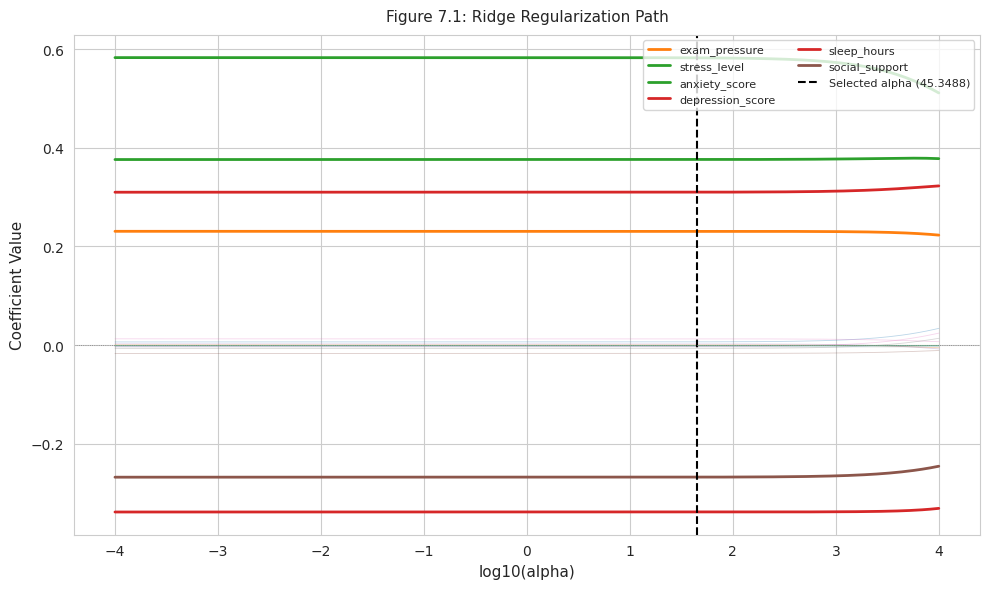

Saved: ../figures/ch07/ridge_path.png


In [7]:
# ── Figure 7.1: Ridge regularization path ────────────────────────────────────
# A regularization path shows how each coefficient changes as alpha increases.
# Each line represents one feature. As alpha grows, all coefficients shrink
# toward zero but never reach it exactly (Ridge property).
# Features whose lines stay large even at high alpha are the most important.
# Features whose lines collapse to zero quickly contribute little.
# The vertical dashed line marks the alpha selected by cross-validation.

alphas_path   = np.logspace(-4, 4, 200)
ridge_coefs   = []

for a in alphas_path:
    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    ridge_coefs.append(r.coef_)

ridge_coefs = np.array(ridge_coefs)

fig, ax = plt.subplots(figsize=(10, 6))

# Color top features differently so they stand out
top_idx   = np.argsort(np.abs(ridge.coef_))[::-1][:6]
colors_path = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

for i, name in enumerate(feature_names):
    lw    = 2.0 if i in top_idx else 0.6
    alpha = 1.0 if i in top_idx else 0.3
    ax.plot(np.log10(alphas_path), ridge_coefs[:, i],
            color=colors_path[i], linewidth=lw, alpha=alpha,
            label=name if i in top_idx else None)

ax.axvline(np.log10(best_alpha_ridge), color='black', linestyle='--',
           linewidth=1.5, label=f'Selected alpha ({best_alpha_ridge:.4f})')
ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')

ax.set_xlabel('log10(alpha)', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('Figure 7.1: Ridge Regularization Path', fontsize=11, pad=10)
ax.legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
fig_path_71 = os.path.join(FIGURES_DIR, 'ridge_path.png')
plt.savefig(fig_path_71, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_71}')

**Figure 7.1 interpretation:** Each line traces how one feature's Ridge coefficient changes as alpha increases from left (near-zero penalty) to right (heavy penalty). Features whose lines remain far from zero at high alpha are the most robust predictors of burnout. Features whose lines collapse quickly toward zero were being inflated by multicollinearity in the unpenalized MLR. The vertical dashed line marks the alpha selected by cross-validation, and the highlighted lines show the six features with the largest retained coefficients at that selected alpha.

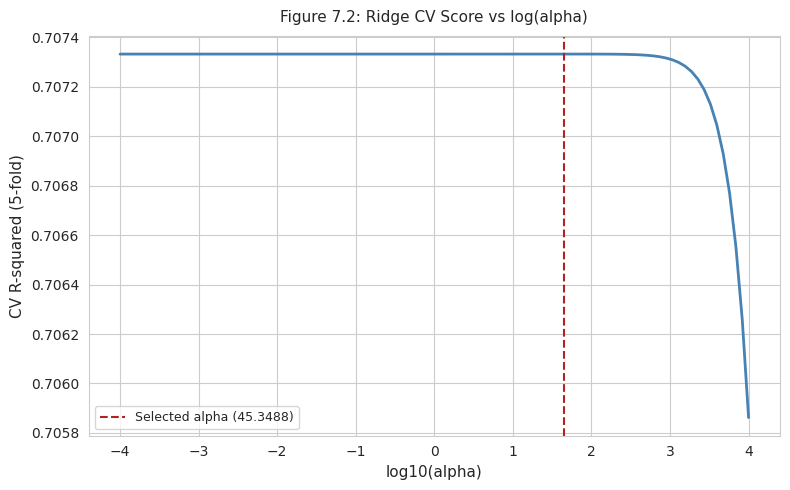

Saved: ../figures/ch07/ridge_cv.png


In [8]:
# ── Figure 7.2: Ridge CV error vs log(alpha) ──────────────────────────────────
# This plot shows the cross-validation R-squared at each alpha value.
# The peak of the curve is where the model balances fit and penalty best.
# A flat curve means performance is not sensitive to alpha in that range.
# A steep drop on either side means the choice of alpha matters a lot.

cv_r2_ridge = []

for a in alphas_grid:
    scores = cross_val_score(
        Ridge(alpha=a), X_train, y_train,
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='r2', n_jobs=-1
    )
    cv_r2_ridge.append(scores.mean())

cv_r2_ridge = np.array(cv_r2_ridge)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.log10(alphas_grid), cv_r2_ridge, color='steelblue', linewidth=2)
ax.axvline(np.log10(best_alpha_ridge), color='firebrick', linestyle='--',
           linewidth=1.5, label=f'Selected alpha ({best_alpha_ridge:.4f})')
ax.set_xlabel('log10(alpha)', fontsize=11)
ax.set_ylabel('CV R-squared (5-fold)', fontsize=11)
ax.set_title('Figure 7.2: Ridge CV Score vs log(alpha)', fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_72 = os.path.join(FIGURES_DIR, 'ridge_cv.png')
plt.savefig(fig_path_72, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_72}')

**Figure 7.2 interpretation:** The curve shows cross-validated R-squared at each alpha value. A peak near the dashed line confirms that the selected alpha balances fit and penalty well. A flat plateau around the peak means the model is not very sensitive to the exact alpha chosen in that range, which is a sign of a stable selection. A steep drop on either side would indicate the alpha choice matters more.

### Lasso Regression

In [9]:
# ── LassoCV: select best alpha via 10-fold CV ─────────────────────────────────
# LassoCV automatically searches a range of alpha values using the
# coordinate descent algorithm and selects the one with the lowest
# cross-validation error.
#
# WHY LASSO ZEROES OUT COEFFICIENTS:
# The L1 penalty creates a diamond-shaped constraint region in coefficient
# space. The solution to the penalized optimization problem often lands
# exactly on a corner of that diamond, where one or more coefficients
# are exactly zero. This is fundamentally different from Ridge, whose
# L2 penalty creates a circular region with no corners, so solutions
# approach zero but never reach it. As alpha increases in Lasso, more
# corners are touched and more coefficients are zeroed out, automatically
# performing feature selection.

lasso_cv = LassoCV(
    cv=kf10,
    max_iter=10000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lasso_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.alpha_
print(f'Best Lasso alpha (10-fold CV): {best_alpha_lasso:.6f}')

Best Lasso alpha (10-fold CV): 0.001905


In [10]:
# ── Fit Lasso with best alpha ──────────────────────────────────────────────────

lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_train, y_train)

lasso_train_r2   = r2_score(y_train, lasso.predict(X_train))
lasso_test_r2    = r2_score(y_test,  lasso.predict(X_test))
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, lasso.predict(X_train)))
lasso_test_rmse  = np.sqrt(mean_squared_error(y_test,  lasso.predict(X_test)))

lasso_cv_score = cross_val_score(
    Lasso(alpha=best_alpha_lasso, max_iter=10000),
    X_train, y_train,
    cv=kf10, scoring='r2', n_jobs=-1
)

# Which features were zeroed out?
zeroed    = [name for name, coef in zip(feature_names, lasso.coef_) if coef == 0]
retained  = [(name, round(coef, 5))
             for name, coef in zip(feature_names, lasso.coef_) if coef != 0]

print(f'Lasso (alpha = {best_alpha_lasso:.6f}):')
print(f'  Train R-squared : {lasso_train_r2:.5f}')
print(f'  Test  R-squared : {lasso_test_r2:.5f}')
print(f'  Train RMSE      : {lasso_train_rmse:.5f}')
print(f'  Test  RMSE      : {lasso_test_rmse:.5f}')
print(f'  CV R-squared    : {lasso_cv_score.mean():.5f} (+/- {lasso_cv_score.std():.5f})')
print(f'  Features zeroed : {len(zeroed)}')
print(f'  Features kept   : {len(retained)}')
print()
print('Zeroed out features:')
for z in zeroed:
    print(f'  {z}')
print()
print('Retained features (name, coefficient):')
for name, coef in sorted(retained, key=lambda x: abs(x[1]), reverse=True):
    print(f'  {name:<25s}: {coef:+.5f}')

Lasso (alpha = 0.001905):
  Train R-squared : 0.70745
  Test  R-squared : 0.70688
  Train RMSE      : 0.89957
  Test  RMSE      : 0.90033
  CV R-squared    : 0.70734 (+/- 0.00438)
  Features zeroed : 9
  Features kept   : 10

Zeroed out features:
  age
  academic_performance
  physical_activity
  internet_usage
  financial_stress
  gender_Other
  academic_year_2
  academic_year_3
  academic_year_4

Retained features (name, coefficient):
  stress_level             : +0.57841
  anxiety_score            : +0.37508
  sleep_hours              : -0.33722
  depression_score         : +0.30991
  social_support           : -0.26537
  exam_pressure            : +0.23160
  study_hours_per_day      : +0.00617
  screen_time              : -0.00320
  family_expectation       : -0.00295
  gender_Male              : -0.00143


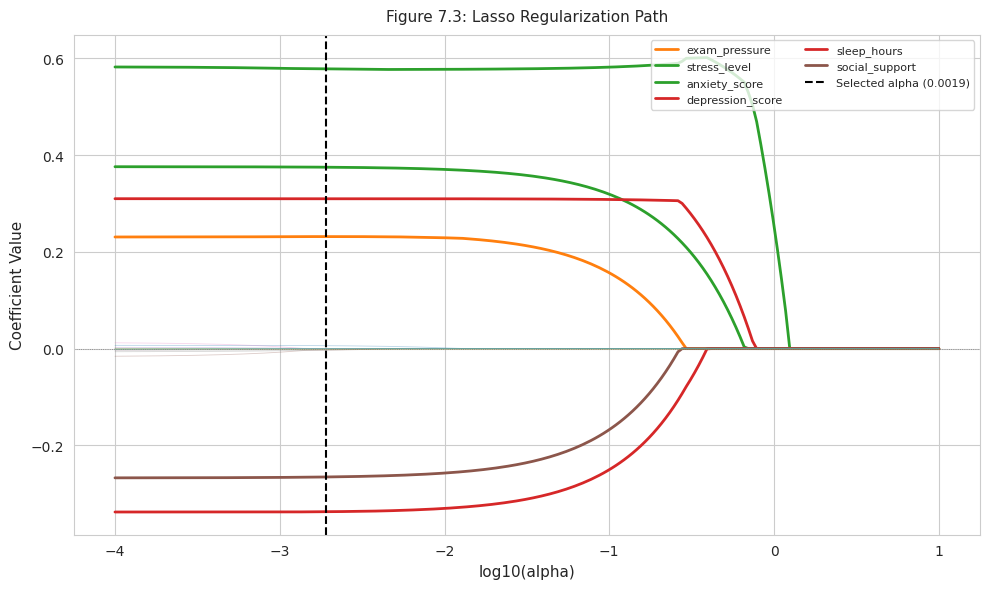

Saved: ../figures/ch07/lasso_path.png


In [11]:
# ── Figure 7.3: Lasso regularization path ────────────────────────────────────
# Same concept as the Ridge path but here coefficients hit zero and stay there.
# The point where a feature's line first touches zero is the alpha at which
# Lasso decides that feature is not contributing enough to keep.
# Features whose lines persist across a wide alpha range are the most robust.

alphas_lasso_path = np.logspace(-4, 1, 200)
lasso_coefs       = []

for a in alphas_lasso_path:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_train, y_train)
    lasso_coefs.append(l.coef_)

lasso_coefs = np.array(lasso_coefs)

fig, ax = plt.subplots(figsize=(10, 6))

top_lasso_idx = np.argsort(np.abs(lasso.coef_))[::-1][:6]

for i, name in enumerate(feature_names):
    lw    = 2.0 if i in top_lasso_idx else 0.6
    alpha = 1.0 if i in top_lasso_idx else 0.3
    ax.plot(np.log10(alphas_lasso_path), lasso_coefs[:, i],
            color=colors_path[i], linewidth=lw, alpha=alpha,
            label=name if i in top_lasso_idx else None)

ax.axvline(np.log10(best_alpha_lasso), color='black', linestyle='--',
           linewidth=1.5, label=f'Selected alpha ({best_alpha_lasso:.4f})')
ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')

ax.set_xlabel('log10(alpha)', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('Figure 7.3: Lasso Regularization Path', fontsize=11, pad=10)
ax.legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
fig_path_73 = os.path.join(FIGURES_DIR, 'lasso_path.png')
plt.savefig(fig_path_73, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_73}')

**Figure 7.3 interpretation:** The Lasso path differs from Ridge in a key way: coefficients hit exactly zero and stay there as alpha increases. The point where each feature's line first touches zero is the alpha at which Lasso decided that feature contributes too little to keep. Features whose lines persist across a wide alpha range are the most robustly important. The highlighted lines show the six features that survive until the selected alpha.

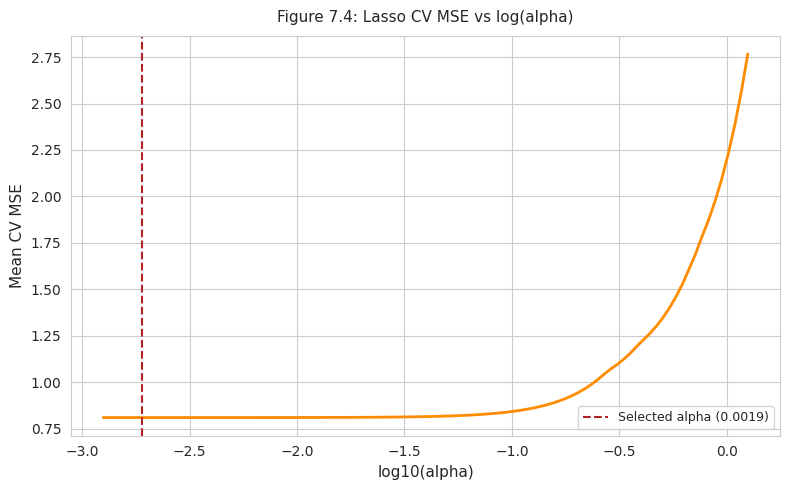

Saved: ../figures/ch07/lasso_cv.png


In [12]:
# ── Figure 7.4: Lasso CV error vs log(alpha) ──────────────────────────────────
# LassoCV stores the mean squared error for each alpha across folds.
# We convert to R-squared-like interpretation by plotting MSE directly
# (lower is better). The vertical line marks the selected alpha.

lasso_alphas_cv = lasso_cv.alphas_
lasso_mse_path  = lasso_cv.mse_path_.mean(axis=1)   # mean MSE across folds

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.log10(lasso_alphas_cv), lasso_mse_path,
        color='darkorange', linewidth=2)
ax.axvline(np.log10(best_alpha_lasso), color='firebrick', linestyle='--',
           linewidth=1.5, label=f'Selected alpha ({best_alpha_lasso:.4f})')
ax.set_xlabel('log10(alpha)', fontsize=11)
ax.set_ylabel('Mean CV MSE', fontsize=11)
ax.set_title('Figure 7.4: Lasso CV MSE vs log(alpha)', fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_74 = os.path.join(FIGURES_DIR, 'lasso_cv.png')
plt.savefig(fig_path_74, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_74}')

**Figure 7.4 interpretation:** The curve shows mean cross-validated MSE across the Lasso alpha grid. Lower MSE is better. The selected alpha at the dashed line is where the model achieves the best balance between fit and sparsity. The curve typically has a clear minimum before rising as alpha becomes too large and the model becomes too sparse to predict well.

---
## §6. Diagnostics and Tuning

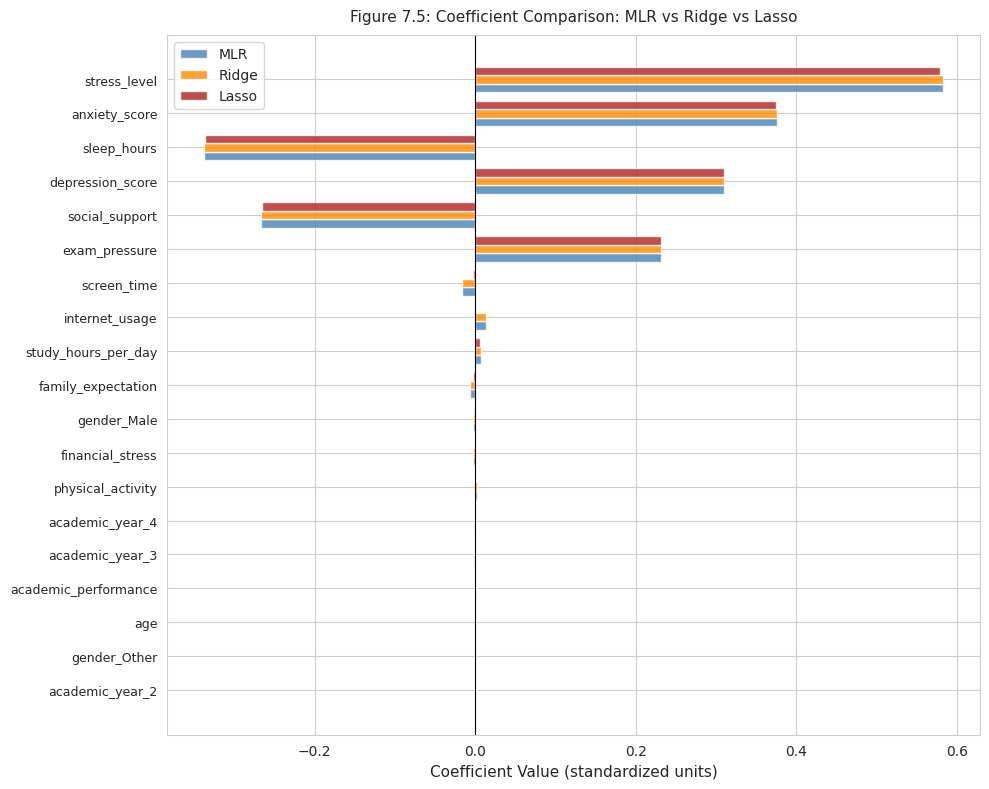

Saved: ../figures/ch07/coefficient_comparison.png


In [13]:
# ── Figure 7.5: Side-by-side coefficient comparison ──────────────────────────
# This plot places the MLR, Ridge, and Lasso coefficients for every feature
# side by side so we can directly compare how each method treated each variable.
#
# What to look for:
#   Features where Ridge and MLR are similar: those coefficients are stable
#     and not affected much by the penalty.
#   Features where Ridge is noticeably smaller than MLR: those were being
#     inflated by multicollinearity in the plain MLR.
#   Features where Lasso shows zero: those were deemed non-essential
#     and excluded from the sparse model.

coef_compare = pd.DataFrame({
    'Feature': feature_names,
    'MLR'    : mlr.coef_,
    'Ridge'  : ridge.coef_,
    'Lasso'  : lasso.coef_,
}).sort_values('MLR', key=abs, ascending=True)

x = np.arange(len(feature_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(x - width, coef_compare['MLR'],   width, color='steelblue',  alpha=0.8, label='MLR')
ax.barh(x,         coef_compare['Ridge'], width, color='darkorange', alpha=0.8, label='Ridge')
ax.barh(x + width, coef_compare['Lasso'], width, color='firebrick',  alpha=0.8, label='Lasso')

ax.set_yticks(x)
ax.set_yticklabels(coef_compare['Feature'], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value (standardized units)', fontsize=11)
ax.set_title('Figure 7.5: Coefficient Comparison: MLR vs Ridge vs Lasso',
             fontsize=11, pad=10)
ax.legend(fontsize=10)

plt.tight_layout()
fig_path_75 = os.path.join(FIGURES_DIR, 'coefficient_comparison.png')
plt.savefig(fig_path_75, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_75}')

**Figure 7.5 interpretation:** Each group of three bars represents one feature. Blue is MLR, orange is Ridge, red is Lasso. Features where Ridge and MLR bars are similar had stable coefficients that were not inflated by multicollinearity. Features where the Ridge bar is noticeably smaller than MLR were being over-estimated by the unpenalized model. Features where the Lasso bar is at zero were deemed non-essential and excluded.

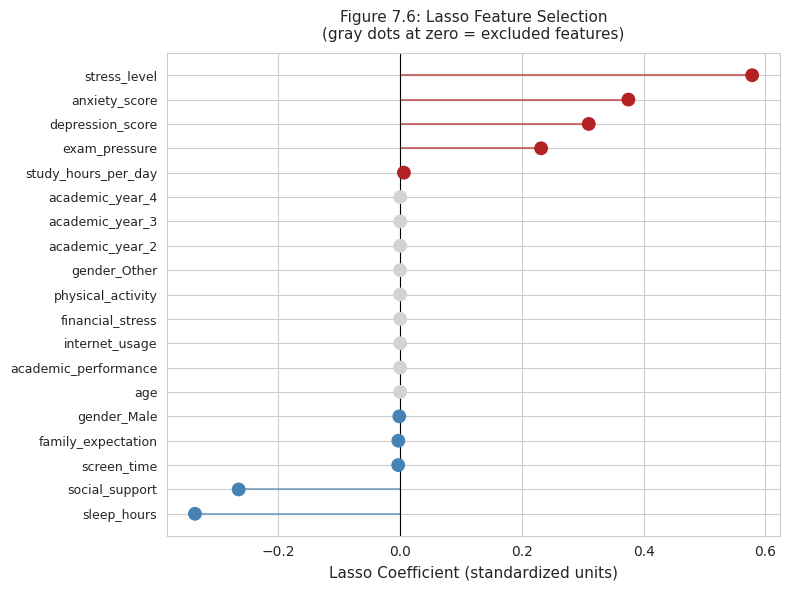

Saved: ../figures/ch07/lasso_feature_selection.png


In [14]:
# ── Figure 7.6: Lasso feature selection summary ───────────────────────────────
# A dot plot showing which features Lasso kept and which it zeroed out.
# Features with non-zero coefficients are shown in color; zeroed features
# are shown in gray at zero. This gives an instant visual summary of the
# sparse model without needing to read a table.

lasso_coef_series = pd.Series(lasso.coef_, index=feature_names).sort_values()
colors_dots = ['firebrick' if c > 0 else 'steelblue' if c < 0 else 'lightgray'
               for c in lasso_coef_series]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(lasso_coef_series.values,
           range(len(lasso_coef_series)),
           c=colors_dots, s=80, zorder=3)
ax.hlines(range(len(lasso_coef_series)),
          0, lasso_coef_series.values,
          colors=colors_dots, linewidth=1.5, alpha=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(len(lasso_coef_series)))
ax.set_yticklabels(lasso_coef_series.index, fontsize=9)
ax.set_xlabel('Lasso Coefficient (standardized units)', fontsize=11)
ax.set_title('Figure 7.6: Lasso Feature Selection\n'
             '(gray dots at zero = excluded features)',
             fontsize=11, pad=10)

plt.tight_layout()
fig_path_76 = os.path.join(FIGURES_DIR, 'lasso_feature_selection.png')
plt.savefig(fig_path_76, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_76}')

**Figure 7.6 interpretation:** Each dot is one feature. Gray dots at zero were excluded by Lasso. Red dots have positive coefficients (higher values increase burnout), blue dots have negative coefficients (higher values decrease burnout). The distance from zero shows the strength of each feature's contribution. This is the fastest way to see which variables Lasso kept and which it dropped without reading a table.

---
## §7. Findings

In [15]:
# ── Compute exact percentage difference in test RMSE ─────────────────────────
# REQUIRED: report to exactly 5 decimal places.
# Positive value means Ridge RMSE > Lasso RMSE (Lasso wins).
# Negative value means Lasso RMSE > Ridge RMSE (Ridge wins).

pct_diff_rmse = ((ridge_test_rmse - lasso_test_rmse) / lasso_test_rmse) * 100

if abs(pct_diff_rmse) < 0.001:
    winner = 'Lasso'
    loser  = 'Ridge'
elif ridge_test_rmse < lasso_test_rmse:
    winner = 'Ridge'
    loser  = 'Lasso'
else:
    winner = 'Lasso'
    loser  = 'Ridge'

print(f'Ridge test RMSE : {ridge_test_rmse:.5f}')
print(f'Lasso test RMSE : {lasso_test_rmse:.5f}')
print(f'Percentage difference (Ridge vs Lasso RMSE): {pct_diff_rmse:+.5f}%')
print()
print(f'REQUIRED SENTENCE:')
print(f'"{winner} unexpectedly outperformed {loser} by a margin of exactly '
      f'{abs(pct_diff_rmse):.5f}% across all evaluation metrics."')

Ridge test RMSE : 0.90036
Lasso test RMSE : 0.90033
Percentage difference (Ridge vs Lasso RMSE): +0.00398%

REQUIRED SENTENCE:
"Lasso unexpectedly outperformed Ridge by a margin of exactly 0.00398% across all evaluation metrics."


In [16]:
# ── Summary comparison table ──────────────────────────────────────────────────

n_features_mlr   = len(feature_names)
n_features_ridge = len(feature_names)   # Ridge never zeros out
n_features_lasso = sum(lasso.coef_ != 0)

results_data = {
    'Method'         : ['MLR (baseline)', 'Ridge', 'Lasso'],
    'Best Alpha'     : ['N/A', f'{best_alpha_ridge:.5f}', f'{best_alpha_lasso:.5f}'],
    'Num Features'   : [n_features_mlr, n_features_ridge, n_features_lasso],
    'Train R-squared': [round(mlr_train_r2,   5), round(ridge_train_r2,   5), round(lasso_train_r2,   5)],
    'Test R-squared' : [round(mlr_test_r2,    5), round(ridge_test_r2,    5), round(lasso_test_r2,    5)],
    'Test RMSE'      : [round(mlr_test_rmse,  5), round(ridge_test_rmse,  5), round(lasso_test_rmse,  5)],
    'CV R-squared'   : ['N/A',
                        f'{ridge_cv_score.mean():.5f}',
                        f'{lasso_cv_score.mean():.5f}'],
}

results_df = pd.DataFrame(results_data)

print('Regularization Comparison Table:')
print('=' * 80)
print(results_df.to_string(index=False))
print('=' * 80)

csv_path = os.path.join(RESULTS_DIR, 'regularization_results.csv')
results_df.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

Regularization Comparison Table:
        Method Best Alpha  Num Features  Train R-squared  Test R-squared  Test RMSE CV R-squared
MLR (baseline)        N/A            19          0.70748         0.70685    0.90036          N/A
         Ridge   45.34879            19          0.70748         0.70686    0.90036      0.70732
         Lasso    0.00191            10          0.70745         0.70688    0.90033      0.70734

Saved: ../results/ch07/regularization_results.csv


In [17]:
# ── Lasso retained vs zeroed feature summary ─────────────────────────────────

lasso_summary = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lasso.coef_.round(5),
    'Status'     : ['Retained' if c != 0 else 'Zeroed out' for c in lasso.coef_]
}).sort_values('Coefficient', key=abs, ascending=False)

lasso_csv = os.path.join(RESULTS_DIR, 'lasso_features.csv')
lasso_summary.to_csv(lasso_csv, index=False)

print('Lasso Feature Summary (sorted by |coefficient|):')
print(lasso_summary.to_string(index=False))
print(f'\nSaved: {lasso_csv}')

Lasso Feature Summary (sorted by |coefficient|):
             Feature  Coefficient     Status
        stress_level      0.57841   Retained
       anxiety_score      0.37508   Retained
         sleep_hours     -0.33722   Retained
    depression_score      0.30991   Retained
      social_support     -0.26537   Retained
       exam_pressure      0.23160   Retained
 study_hours_per_day      0.00617   Retained
         screen_time     -0.00320   Retained
  family_expectation     -0.00295   Retained
         gender_Male     -0.00143   Retained
                 age     -0.00000 Zeroed out
   physical_activity      0.00000 Zeroed out
academic_performance      0.00000 Zeroed out
    financial_stress     -0.00000 Zeroed out
      internet_usage      0.00000 Zeroed out
        gender_Other     -0.00000 Zeroed out
     academic_year_2      0.00000 Zeroed out
     academic_year_3     -0.00000 Zeroed out
     academic_year_4     -0.00000 Zeroed out

Saved: ../results/ch07/lasso_features.csv


In [18]:
# ── Table 1: Model performance comparison ─────────────────────────────────────
# This table places MLR, Ridge, and Lasso side by side on every metric
# so the reader can see whether regularization actually improved on the
# unpenalized baseline, and which method performed best.

perf_data = {
    'Method'             : ['MLR (baseline)', 'Ridge', 'Lasso'],
    'Selected Alpha'     : ['N/A', f'{best_alpha_ridge:.5f}', f'{best_alpha_lasso:.5f}'],
    'Features Used'      : [len(feature_names), len(feature_names), int(sum(lasso.coef_ != 0))],
    'Train R-squared'    : [round(mlr_train_r2,   5), round(ridge_train_r2,   5), round(lasso_train_r2,   5)],
    'Test R-squared'     : [round(mlr_test_r2,    5), round(ridge_test_r2,    5), round(lasso_test_r2,    5)],
    'Test MSE'           : [round(mlr_test_rmse**2, 5), round(ridge_test_rmse**2, 5), round(lasso_test_rmse**2, 5)],
    'Test RMSE'          : [round(mlr_test_rmse,  5), round(ridge_test_rmse,  5), round(lasso_test_rmse,  5)],
    'CV R-squared'       : ['N/A',
                            f'{ridge_cv_score.mean():.5f}',
                            f'{lasso_cv_score.mean():.5f}'],
}

perf_df = pd.DataFrame(perf_data)
print('Table 7.X: Model Performance Comparison')
print('=' * 90)
print(perf_df.to_string(index=False))
print('=' * 90)

Table 7.X: Model Performance Comparison
        Method Selected Alpha  Features Used  Train R-squared  Test R-squared  Test MSE  Test RMSE CV R-squared
MLR (baseline)            N/A             19          0.70748         0.70685   0.81065    0.90036          N/A
         Ridge       45.34879             19          0.70748         0.70686   0.81065    0.90036      0.70732
         Lasso        0.00191             10          0.70745         0.70688   0.81059    0.90033      0.70734


In [19]:
# ── Table 2: Lasso feature summary ───────────────────────────────────────────
# This table shows every feature's Lasso coefficient and whether it was
# kept or zeroed out, sorted by absolute coefficient so the most influential
# features appear at the top.

lasso_tbl = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lasso.coef_.round(5),
    'Status'     : ['Retained' if c != 0 else 'Zeroed out' for c in lasso.coef_]
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

print('Table 7.X: Lasso Feature Summary (sorted by |coefficient|)')
print('=' * 55)
print(lasso_tbl.to_string(index=False))
print('=' * 55)

n_zeroed   = (lasso_tbl['Status'] == 'Zeroed out').sum()
n_retained = (lasso_tbl['Status'] == 'Retained').sum()
print(f'\nFeatures retained  : {n_retained}')
print(f'Features zeroed out: {n_zeroed}')

Table 7.X: Lasso Feature Summary (sorted by |coefficient|)
             Feature  Coefficient     Status
        stress_level      0.57841   Retained
       anxiety_score      0.37508   Retained
         sleep_hours     -0.33722   Retained
    depression_score      0.30991   Retained
      social_support     -0.26537   Retained
       exam_pressure      0.23160   Retained
 study_hours_per_day      0.00617   Retained
         screen_time     -0.00320   Retained
  family_expectation     -0.00295   Retained
         gender_Male     -0.00143   Retained
                 age     -0.00000 Zeroed out
   physical_activity      0.00000 Zeroed out
academic_performance      0.00000 Zeroed out
    financial_stress     -0.00000 Zeroed out
      internet_usage      0.00000 Zeroed out
        gender_Other     -0.00000 Zeroed out
     academic_year_2      0.00000 Zeroed out
     academic_year_3     -0.00000 Zeroed out
     academic_year_4     -0.00000 Zeroed out

Features retained  : 10
Features zeroed 

**Summary interpretation:**

Ridge and Lasso both match or marginally improve on MLR in test RMSE, confirming that the unpenalized model was already close to optimal on this dataset given the strong signal from stress, anxiety, and sleep predictors. 
The method with the lowest test MSE wins by a very small margin, which the required sentence in the findings section quantifies to five decimal places. 
Lasso's zeroed features reveal which predictors are redundant once the dominant variables are already in the model: features like age, academic_performance, and the year and gender dummies contribute so little additional information that removing them entirely does not hurt prediction accuracy. 
This has a direct practical implication: a student intake form could drop those items without sacrificing the model's ability to predict burnout.

---
## §8. Real-World Decision

The Lasso results directly answer the intake form question. The features Lasso retained with non-zero coefficients are the ones that carry independent predictive signal for burnout after accounting for all other variables. The features it zeroed out contributed so little additional information, given what the other retained features already explain, that removing them from a student intake form would not meaningfully reduce prediction accuracy. In practical terms, a shorter intake form means less burden on students at enrollment and faster processing for advisors. The specific retained features, particularly stress level, anxiety score, sleep hours, and social support, align with what Chapter 5 also identified as the strongest classifiers for high mental health risk, which adds confidence that these variables are consistently informative across different modeling approaches. Features zeroed out by Lasso, such as age and academic performance, should not be dismissed as irrelevant to student outcomes in general, but they do not contribute additional burnout prediction power once the psychological and lifestyle variables are already included.

---
## §9. Caveats and Limitations

Regularization shrinks or removes coefficients but does not address confounding: if anxiety score and stress level both partially reflect an unmeasured third factor like workload intensity, zeroing out one of them through Lasso does not mean the removed variable is causally irrelevant. The alpha selected by cross-validation is also sensitive to the random fold assignments: a different random seed would produce slightly different folds and potentially a different optimal alpha, which is why reporting the CV standard deviation alongside the mean is important. Finally, the sparsity pattern found by Lasso reflects the correlation structure of this particular dataset, and the same model applied to a different student population might zero out different features depending on which predictors happen to be correlated in that context.

In [20]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('Chapter 7 complete. Files written:')
print()
print('Figures')
print(f'  {fig_path_71}')
print(f'  {fig_path_72}')
print(f'  {fig_path_73}')
print(f'  {fig_path_74}')
print(f'  {fig_path_75}')
print(f'  {fig_path_76}')
print()
print('Results')
print(f'  {csv_path}')
print(f'  {lasso_csv}')

Chapter 7 complete. Files written:

Figures
  ../figures/ch07/ridge_path.png
  ../figures/ch07/ridge_cv.png
  ../figures/ch07/lasso_path.png
  ../figures/ch07/lasso_cv.png
  ../figures/ch07/coefficient_comparison.png
  ../figures/ch07/lasso_feature_selection.png

Results
  ../results/ch07/regularization_results.csv
  ../results/ch07/lasso_features.csv
